In [1]:
## 데이터 분석 & 시각화 도구 library 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error

In [2]:
## 가상의 고객 나이와 지출 데이터 생성하고 결측치 삽입
## 데이터 생성함수 (기본값: n=100)
def create_customer_data(n=100):
  np.random.seed(42)
  age = np.random.normal(40, 10, n)  # N(40,100)에서 100개의 데이터
  spending = age*20 + np.random.normal(0, 50, n)
  return pd.DataFrame({'age': age, 'spending': spending})

## 결측치 생성함수
## 기본값 spending 컬럼에 삽입. 결측치 비율: 0.1 즉, 10%
def insert_missing_value(df, col='spending', missing_rate=0.1):
  df_missing = df.copy()
  n = len(df_missing)

  # n중에서 중복없이 n*0.1만큼 무작위 비복원추출로 인덱스 선택
  missing_indices = np.random.choice(n, size=int(n*missing_rate), replace=False)

  # 선택된 위치에 NaN 삽입
  df_missing.loc[missing_indices, col] = np.nan
  return df_missing

In [3]:
## 결측치 채우고, 선형 회귀 모델 학습한 뒤, 성능(MSE)과 회귀계수 반환
def regression_with_imputation(df, method='mean'):
  df_copy = df.copy()

  if method == 'mean':
    df_copy['spending'] = df_copy['spending'].fillna(df_copy['spending'].mean())

  elif method == 'zero':
    df_copy['spending'] = df_copy['spending'].fillna(0)

  elif method == 'knn':
    imputer = KNNImputer(n_neighbors=3)
    df_copy = pd.DataFrame(imputer.fit_transform(df_copy), columns=df.columns)

  elif method == 'linear':
    df_copy['spending'] = df_copy['spending'].interpolate(method='linear')

  else:
    raise ValueError(f"Unknown Imputation Method: {method}")

  ## 회귀분석
  X = df_copy[['age']]
  y = df_copy['spending']
  model = LinearRegression()
  model.fit(X, y)
  pred = model.predict(X)

  ## MSE 계산
  mse = mean_squared_error(y, pred)

  ## 예측성능지표, 회귀계수, 절편 반환
  return mse, model.coef_[0], model.intercept_

In [4]:
## 결측치가 포함된 고객 데이터를 다양한 방식으로 채우고,
## 선형 회귀를 학습해서 각 방식의 성능과 회귀 계수(기울기, 절편)을 비교

## 고객 데이터 생성
df = create_customer_data()

## 결측치 삽입
df_missing = insert_missing_value(df, col='spending', missing_rate=0.1)

## 결측치 대체 방법 정의
methods = ['mean', 'zero', 'knn', 'linear']

## 결과 저장용 리스트 초기화
results =[]

## 각 방식별 처리, 회귀, 평가
for method in methods:
  mse, coef, intercept = regression_with_imputation(df_missing, method=method)
  results.append({
      'Method': method,
      'MSE': round(mse, 2),
      'Coef': round(coef, 2),
      'Intercept': round(intercept, 2)
  })

results_df = pd.DataFrame(results)
print(results_df)

   Method       MSE   Coef  Intercept
0    mean   3244.31  18.34      65.09
1    zero  62695.97  16.69      51.54
2     knn   2002.31  19.26      32.88
3  linear   4196.60  18.35      64.28


## 결측치 대체 방법별 회귀선 그리고, 원본 데이터와 비교해보기

In [5]:
## 함수 선언
def plot_imputation_vs_original(df_original, df_missing, methods=['mean', 'zero', 'knn', 'linear']):

  # subplot 설정
  total = len(methods) + 1
  plt.figure(figsize = (5*total, 5))


  # 원본 데이터 회귀선
  X_orig = df_original[['age']]
  y_orig = df_original['spending']
  model_orig = LinearRegression().fit(X_orig, y_orig)
  pred_orig = model_orig.predict(X_orig)

  # MSE 계산
  mse_orig = mean_squared_error(y_orig, pred_orig)


  # 첫 번째 subplot
  plt.subplot(1, total, 1)
  # 원본데이터 점 찍기
  plt.scatter(df_original['age'], df_original['spending'], label='Original Data', alpha=0.6)
  # 원본 회귀선 그리기
  plt.plot(df_original['age'], pred_orig, color='green', label='Original Regression')
  plt.title(f"Original\ny = {model_orig.coef_[0]: .2f}x + {model_orig.intercept_: .2f} | MSE = {mse_orig: .1f}")
  plt.xlabel("Age")
  plt.ylabel("Spending")
  plt.legend()


  # 각 대체 방법별 결측치 채우기 + 회귀선 그리기
  for i, method in enumerate(methods):
    df_copy = df_missing.copy()

    # 방법별 결측치 처리
    if method == 'mean':
      df_copy['spending'] = df_copy['spending'].fillna(df_copy['spending'].mean())
    elif method == 'zero':
      df_copy['spending'] = df_copy['spending'].fillna(0)
    elif method == 'knn':
      imputer = KNNImputer(n_neighbors=3)
      df_copy = pd.DataFrame(imputer.fit_transform(df_copy), columns=df_copy.columns)
    elif method == 'linear':
      df_copy['spending'] = df_copy['spending'].interpolate(method='linear')


    # 회귀분석 및 시각화
    X = df_copy[['age']]
    y = df_copy['spending']
    model = LinearRegression().fit(X, y)
    pred = model.predict(X)

    # MSE 계산 (비교 기준은 원본의 spending)
    mse = mean_squared_error(df_original['spending'], pred)


    # subplot 그리기
    plt.subplot(1, total, i+2)
    # 대체 데이터 점 찍기
    plt.scatter(df_copy['age'], df_copy['spending'], alpha=0.6, label='Imputed')
    # 데체 데이터의 회귀선 그리기
    plt.plot(df_copy['age'], pred, color='red', label='Regression Line')
    plt.title(f"{method.upper()} apply\n"
              f"y = {model.coef_[0]: .2f}x + {model.intercept_: .2f} | MSE = {mse: .1f}")
    plt.xlabel("Age")
    plt.ylabel("Spending")
    plt.legend()

  # 전체 레이아웃 정리
  plt.tight_layout()
  plt.suptitle("Original Vs Method Regression Line", fontsize=16, y=1.02)
  plt.show()

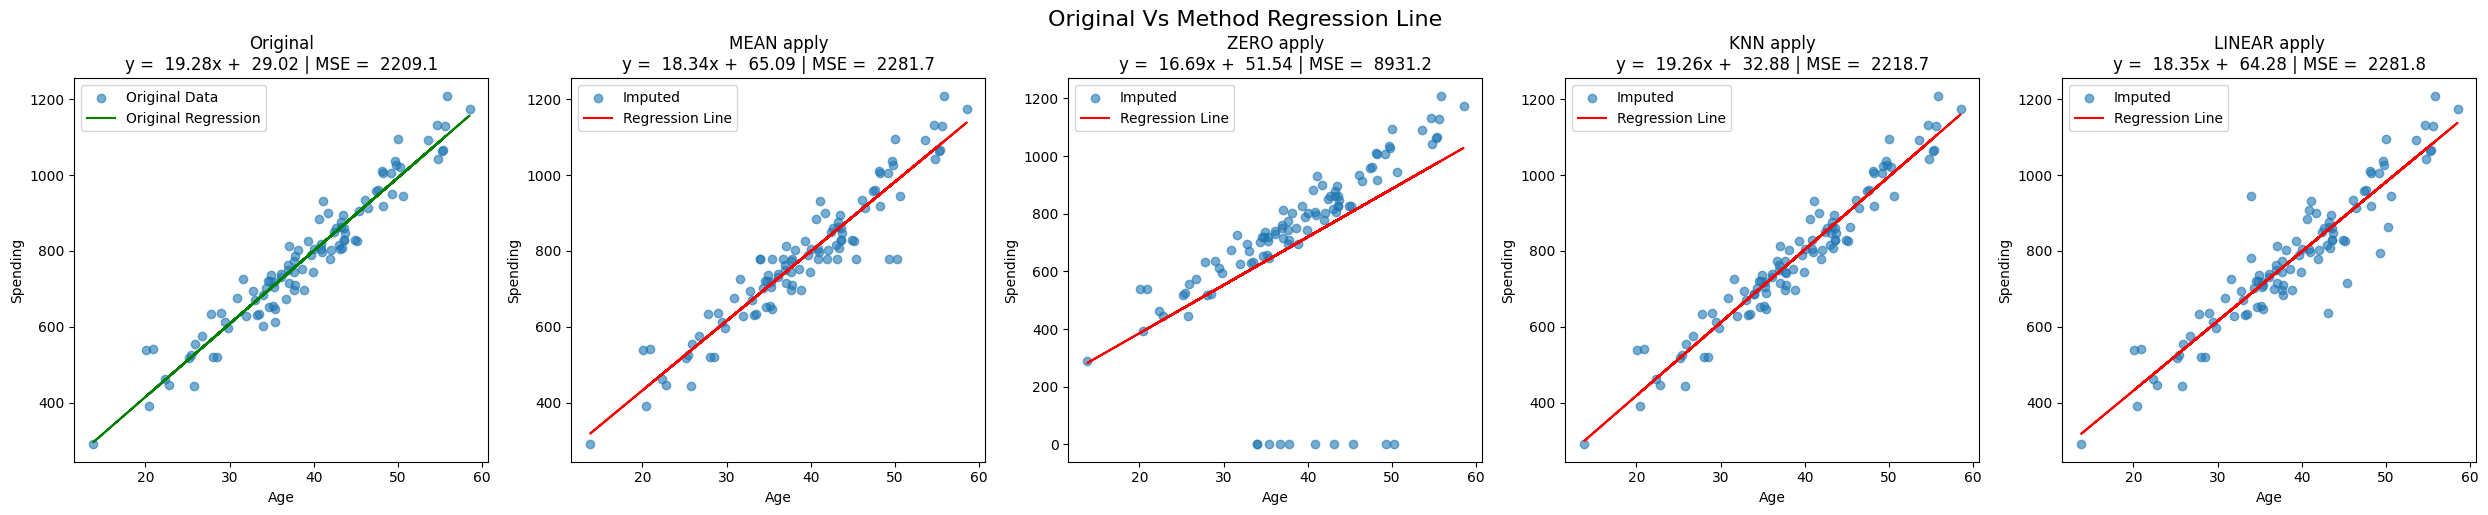

In [6]:
## 원본데이터 생성
df_original = create_customer_data()

## 결측치 포함된 데이터
df_missing = insert_missing_value(df_original, missing_rate=0.1)

## 시각화 실행
plot_imputation_vs_original(df_original, df_missing)

## 고객 데이터를 만들고, 특정 나이에 가장 가까운 행의 지출 값을 결측치로 만든 뒤, 복원해보기

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer

In [8]:
## 원본 데이터 생성
def create_customer_data(n=100):
  np.random.seed(42)
  age = np.random.normal(40, 10, n)
  spending = age*20 + np.random.normal(0, 50, n)
  return pd.DataFrame({'age':age, 'spending':spending})

## 특정 age 근처 row의 spending 값을 NaN으로 만들기
def insert_missing_target(df, target_age=50, tolerance=0.5):
  df_copy = df.copy()

  # target row 찾기
  target_row = df_copy[np.abs(df_copy['age'] - target_age) < tolerance]
  if target_row.empty:
    raise ValueError("NO row found near the target age.")

  # target row의 인덱스 및 실제 값 저장
  idx = target_row.index[0]
  true_age = df_copy.at[idx, 'age']
  true_spending = df_copy.at[idx, 'spending']

  # 해당 spending을 NaN으로 만들기
  df_copy.at[idx, 'spending'] = np.nan

  return df_copy, idx, true_age, true_spending

In [11]:
## 각 방법별로 결측체 대체 + 회귀분석 + 예측
def train_and_predict(df_missing, idx, true_age, true_spending):
  methods = ['mean', 'zero', 'knn', 'linear']
  results = []

  for method in methods:
    df_copy = df_missing.copy()

    # 결측치 대체
    if method == 'mean':
      df_copy['spending'] = df_copy['spending'].fillna(df_copy['spending'].mean())
    elif method == 'zero':
      df_copy['spending'] = df_copy['spending'].fillna(0)
    elif method == 'knn':
      imputer = KNNImputer(n_neighbors=3)
      df_copy = pd.DataFrame(imputer.fit_transform(df_copy), columns=df_copy.columns)
    elif method == 'linear':
      df_copy['spending'] = df_copy['spending'].interpolate(method='linear')

    # 회귀 모델 학습
    X = df_copy[['age']]
    y = df_copy['spending']
    model = LinearRegression().fit(X,y)

    # 특정 나이의 예측값 계산
    spending_hat = model.predict([[true_age]])[0]

    # 예측 오차
    abs_error = abs(spending_hat - true_spending)

    results.append({
        'Method': method,
        'Predicted Spending': round(spending_hat, 2),
        'True Spending': round(true_spending, 2),
        'Prediction Error': round(abs_error, 2)
    })

  return pd.DataFrame(results)

In [12]:
## 원본 생성
df_original = create_customer_data()

## 특정 나이(50세) 주변에 결측치 삽입
df_missing, idx, true_age, true_spending = insert_missing_target(df_original, target_age=30)

## 모델 예측 및 결과 비교
result = train_and_predict(df_missing, idx, true_age, true_spending)

## 결과 출력
from IPython.display import display
display(result)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Method,Predicted Spending,True Spending,Prediction Error
0,mean,608.81,595.7,13.11
1,zero,593.07,595.7,2.62
2,knn,605.98,595.7,10.28
3,linear,608.24,595.7,12.54


In [15]:
## 결측치 처리 방식별 선형 회귀식 출력
def print_regression_equations(df_missing, methods=['mean', 'zero', 'knn', 'linear']):

  ## 결측치 대체 방식별
  for method in methods:
    df_copy = df_missing.copy()
    if method == 'mean':
        df_copy['spending'] = df_copy['spending'].fillna(df_copy['spending'].mean())
    elif method == 'zero':
        df_copy['spending'] = df_copy['spending'].fillna(0)
    elif method == 'knn':
        imputer = KNNImputer(n_neighbors=3)
        df_copy = pd.DataFrame(imputer.fit_transform(df_copy), columns=df_copy.columns)
    elif method == 'linear':
        df_copy['spending'] = df_copy['spending'].interpolate(method='linear')

    model = LinearRegression().fit(df_copy[['age']], df_copy['spending'])
    print(f"{method.upper()} 회귀식: y = {model.coef_[0]: .2f} * age + {model.intercept_: .2f}")

In [16]:
print_regression_equations(df_missing)

MEAN 회귀식: y =  19.08 * age +  38.98
ZERO 회귀식: y =  19.95 * age + -2.77
KNN 회귀식: y =  19.23 * age +  31.46
LINEAR 회귀식: y =  19.11 * age +  37.45


In [21]:
## 원본 데이터 vs 다양한 결측치 대체 방식 시각 비교
def visualize_all_methods(df_original, df_missing, idx, true_age, true_spending):
  methods = ['original', 'mean', 'zero', 'knn', 'linear']
  colors = {'original':'green', 'mean':'blue', 'zero':'purple', 'knn':'orange', 'linear':'teal'}
  plt.figure(figsize = (25, 5))

  # 각 방식별 subplot 생성
  for i, method in enumerate(methods):

    if method == 'original':
      df_copy = df_original.copy()
    else:
      df_copy = df_missing.copy()

      if method == 'mean':
          df_copy['spending'] = df_copy['spending'].fillna(df_copy['spending'].mean())
      elif method == 'zero':
          df_copy['spending'] = df_copy['spending'].fillna(0)
      elif method == 'knn':
          imputer = KNNImputer(n_neighbors=3)
          df_copy = pd.DataFrame(imputer.fit_transform(df_copy), columns=df_copy.columns)
      elif method == 'linear':
          df_copy['spending'] = df_copy['spending'].interpolate(method='linear')


    ## 회귀모델 학습 및 예측
    X = df_copy[['age']]
    y = df_copy['spending']
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    y_hat = model.predict([[true_age]])[0]
    error = abs(y_hat - true_spending)


    ## 시각화
    plt.subplot(1, len(methods), i+1)
    # 데이터 산점도
    plt.scatter(df_copy['age'], df_copy['spending'], alpha=0.6, label='Data')
    # 회귀선
    plt.plot(df_copy['age'], y_pred, color=colors[method], label='Regression')
    # 실제값 표시
    plt.scatter([true_age], [true_spending], color='green', label='True Value', zorder=5, s=80)


    ## 예측값 및 오차 표시 (원본 제외)
    if method != 'original':
      plt.scatter([true_age], [y_hat], color='red', label='Predicted', zorder=5, s=80)
      plt.plot([true_age, true_age], [true_spending, y_hat], 'k--', linewidth=1.5, label='Error')
      plt.title(f"{method.upper()}\npredict = {y_hat: .1f}, error = {error: .1f}")
    else:
      plt.title("ORIGINAL\n True")

    # 축, 레이블, 범례
    plt.xlabel("Age")
    plt.ylabel("Spending")
    plt.legend()

  # 전체 layout 정리
  plt.tight_layout()
  plt.suptitle("Original Vs Methods", fontsize=16, y=1.05)
  plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


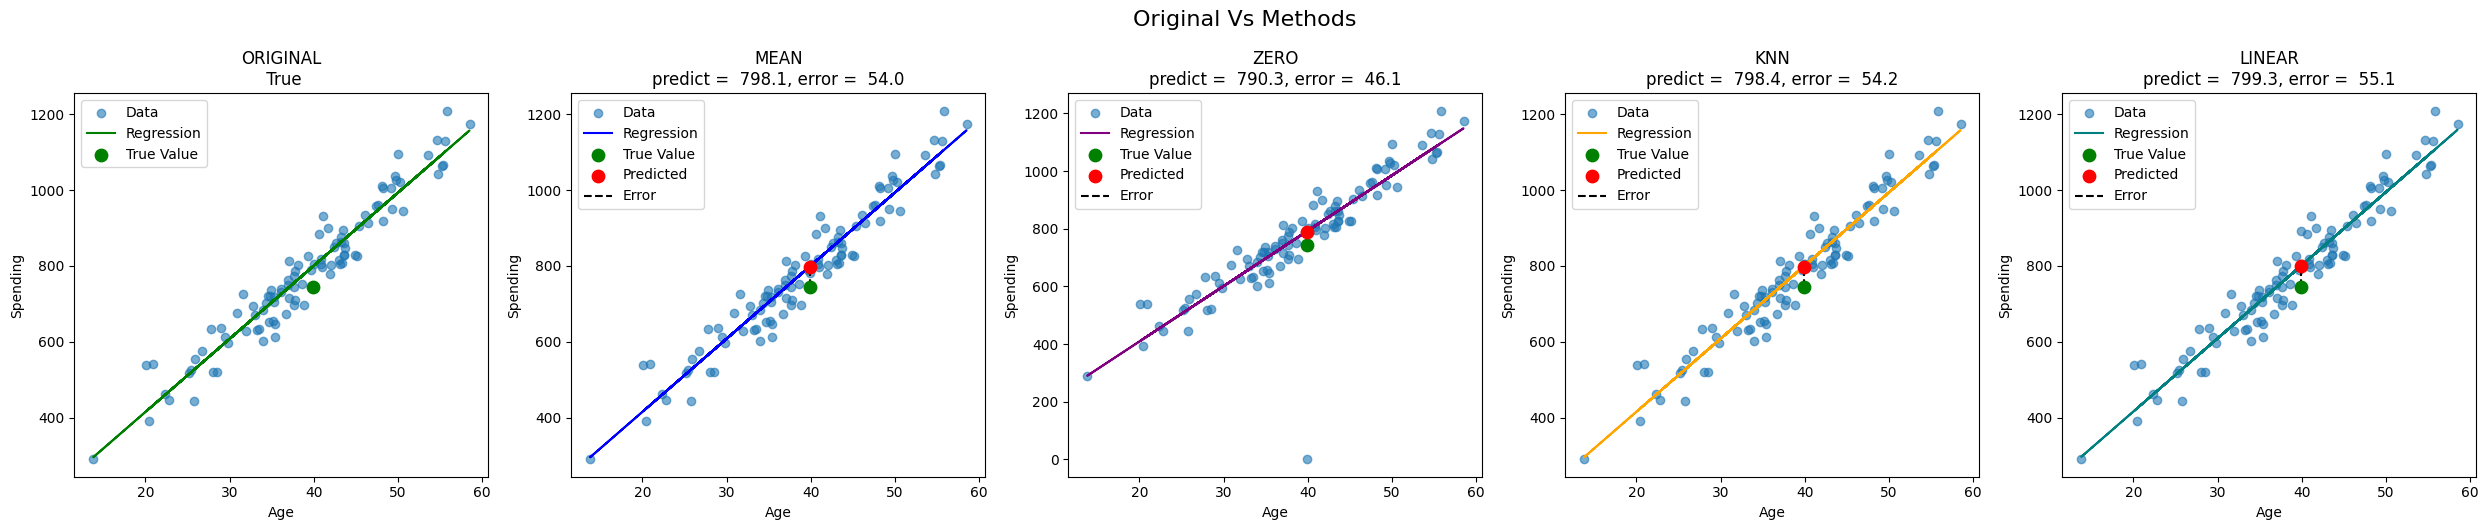

In [22]:
## 원본 생성
df_original = create_customer_data()

## 나이 50 근처 결측치 생성
df_missing, idx, true_age, true_spending = insert_missing_target(df_original, target_age=40)

## 시각화 실행
visualize_all_methods(df_original, df_missing, idx, true_age, true_spending)